# Appliances Energy Prediction — Regression Assignment
Predicting `Appliances_Wh` (10-minute interval energy use) from indoor sensor readings, outdoor weather, and time.

**Dataset:** UCI Appliances Energy Prediction (Candanedo et al., 2017), 19,735 rows, 11-Jan-2016 to 27-May-2016.
**Split:** Chronological — first 75% = Train, last 25% = Test (Test starts 23-Apr-2016 11:50). No shuffling.
**Benchmark to beat:** Original paper reports test R² ≈ 0.57 with Gradient Boosting.

This notebook runs top-to-bottom in Google Colab.

## 0. Setup

In [1]:
!pip install -q lightgbm xgboost shap catboost --no-warn-script-location

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Load the data
Upload `appliances_energy_data.csv` to the Colab session (left sidebar → Files → Upload), or mount Drive and point the path there.

In [3]:
from google.colab import files
# Run this cell and choose the CSV when prompted (skip if already uploaded / using Drive instead)
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0] if uploaded else "appliances_energy_data.csv"


Saving Appliances_Energy_Regression_Dataset.xlsx to Appliances_Energy_Regression_Dataset.xlsx


In [4]:
df = pd.read_excel(DATA_PATH, sheet_name="Data", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(19735, 30)


,date,Split,Appliances_Wh,Lights_Wh,T1,RH_1,T2,RH_2,T3,RH_3,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,Train,60,30,19.89,47.597,19.2,44.790,19.79,44.730,...,17.033,45.53,6.600,733.5,92.0,7.000,63.000,5.3,13.275,13.275
1,2016-01-11 17:10:00,Train,60,30,19.89,46.693,19.2,44.722,19.79,44.790,...,17.067,45.56,6.483,733.6,92.0,6.667,59.167,5.2,18.606,18.606
2,2016-01-11 17:20:00,Train,50,30,19.89,46.300,19.2,44.627,19.79,44.933,...,17.000,45.50,6.367,733.7,92.0,6.333,55.333,5.1,28.643,28.643
3,2016-01-11 17:30:00,Train,50,40,19.89,46.067,19.2,44.590,19.79,45.000,...,17.000,45.40,6.250,733.8,92.0,6.000,51.500,5.0,45.410,45.410
4,2016-01-11 17:40:00,Train,60,40,19.89,46.333,19.2,44.530,19.79,45.000,...,17.000,45.40,6.133,733.9,92.0,5.667,47.667,4.9,10.084,10.084


## 1. Exploratory Data Analysis

In [5]:
df["Appliances_Wh"].describe()

,Appliances_Wh
count,19735.000000
mean,97.694958
std,102.524891
min,10.000000
25%,50.000000
50%,60.000000
75%,100.000000
max,1080.000000


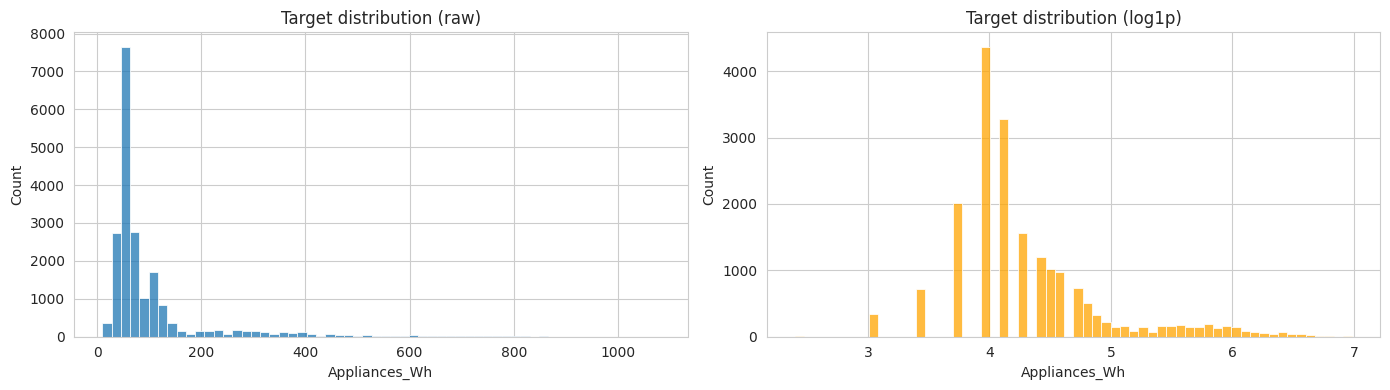

Skewness raw: 3.39 | log1p: 1.19


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["Appliances_Wh"], bins=60, ax=axes[0])
axes[0].set_title("Target distribution (raw)")
sns.histplot(np.log1p(df["Appliances_Wh"]), bins=60, ax=axes[1], color="orange")
axes[1].set_title("Target distribution (log1p)")
plt.tight_layout(); plt.show()
print(f"Skewness raw: {df['Appliances_Wh'].skew():.2f} | log1p: {np.log1p(df['Appliances_Wh']).skew():.2f}")

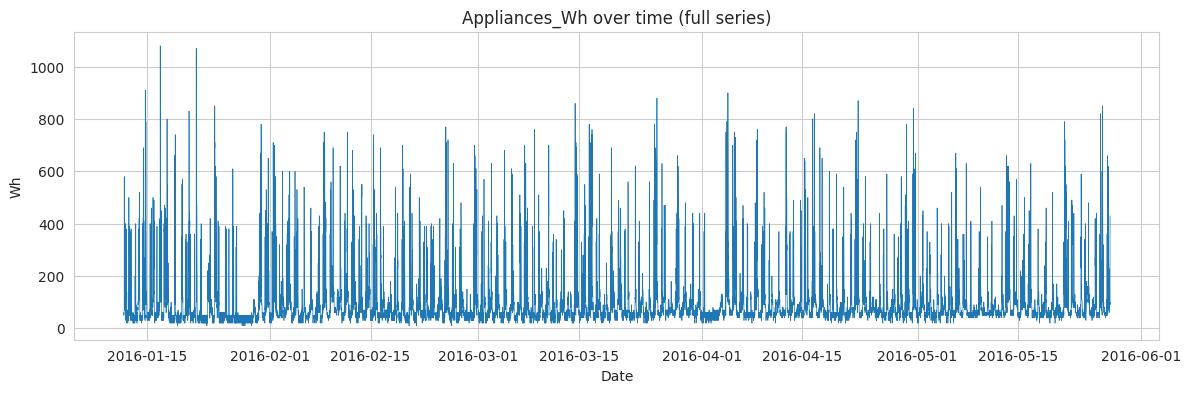

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(df["date"], df["Appliances_Wh"], linewidth=0.5)
plt.title("Appliances_Wh over time (full series)")
plt.xlabel("Date"); plt.ylabel("Wh")
plt.show()

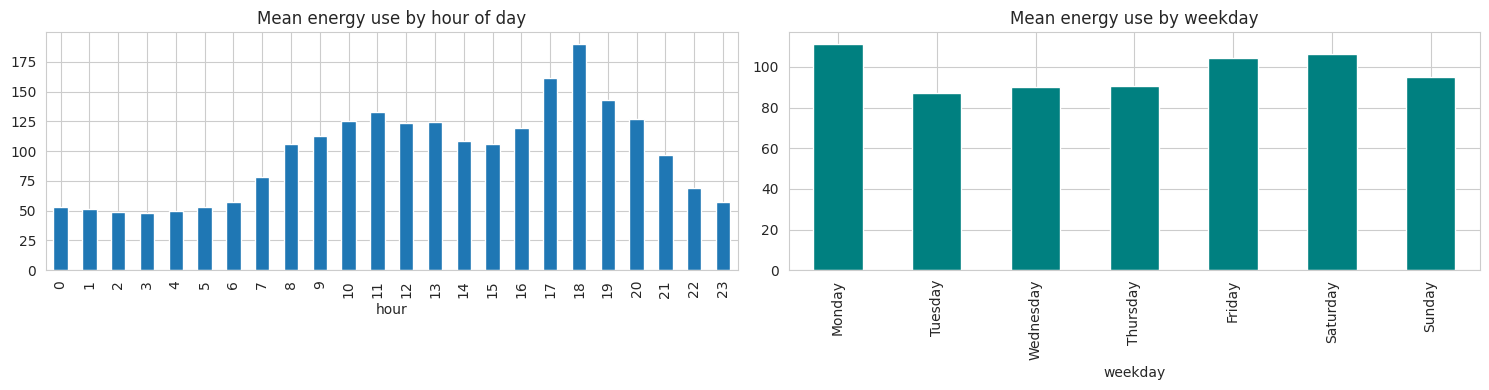

In [8]:
tmp = df.copy()
tmp["hour"] = tmp["date"].dt.hour
tmp["weekday"] = tmp["date"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
tmp.groupby("hour")["Appliances_Wh"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Mean energy use by hour of day")
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
tmp.groupby("weekday")["Appliances_Wh"].mean().reindex(order).plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Mean energy use by weekday")
plt.tight_layout(); plt.show()

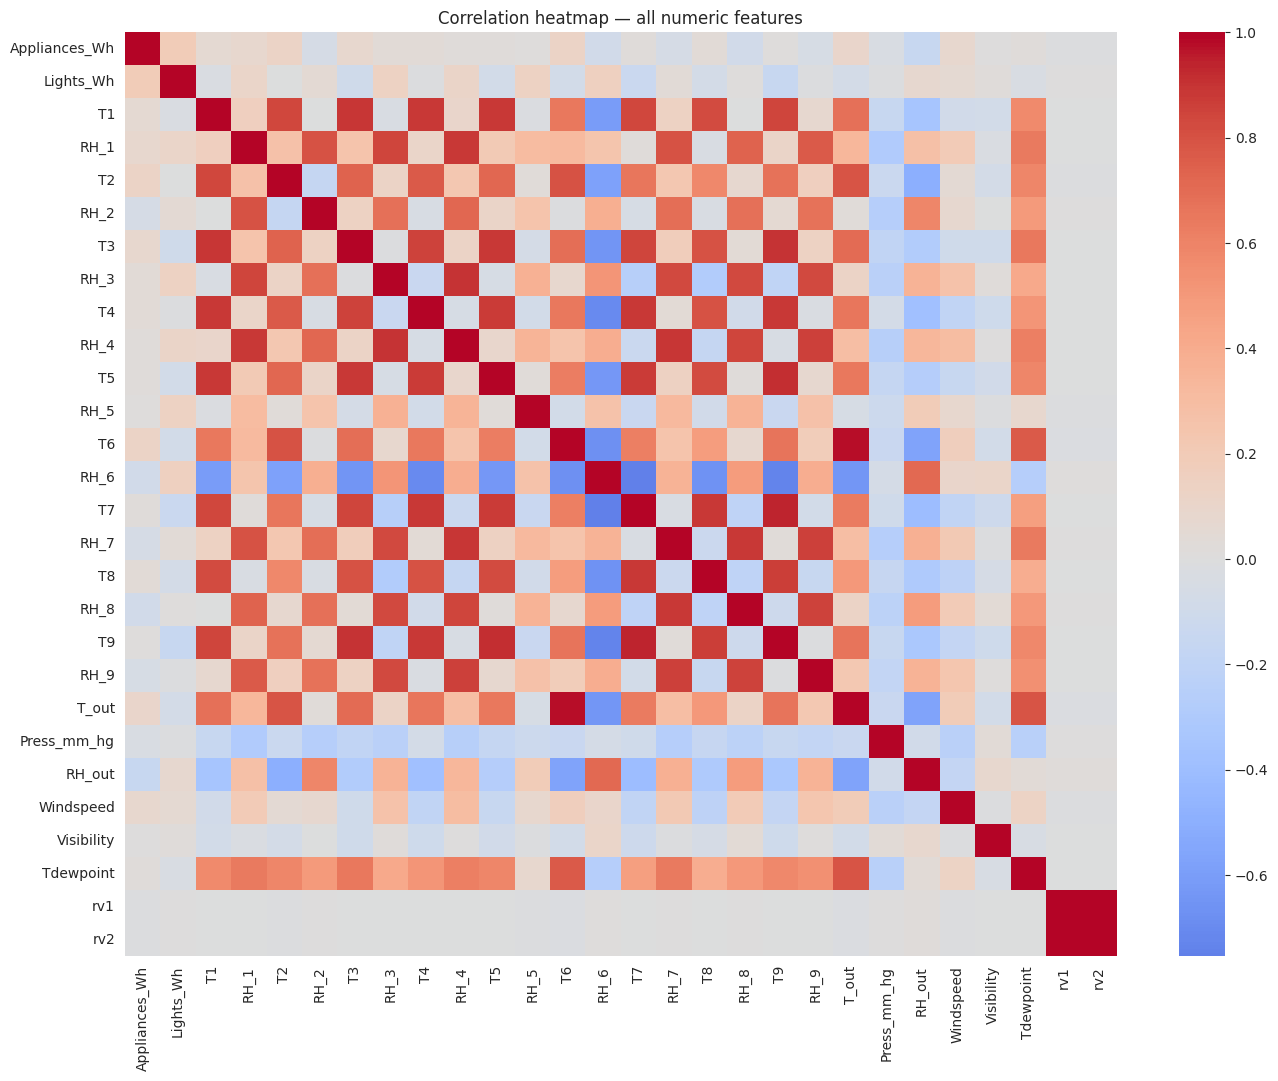

Top correlations with target:
Appliances_Wh    1.000000
Lights_Wh        0.197278
T2               0.120073
T6               0.117637
T_out            0.099154
Windspeed        0.087123
RH_1             0.086032
T3               0.085060
T1               0.055447
T4               0.040280
Name: Appliances_Wh, dtype: float64


In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap — all numeric features")
plt.show()

print("Top correlations with target:")
print(corr["Appliances_Wh"].sort_values(ascending=False).head(10))

**Written insights (fill in / adjust after running):**
1. `Appliances_Wh` is strongly right-skewed with a long tail of high-usage spikes — `log1p` makes it far more symmetric, which is why we'll compare raw vs log-target models.
2. Energy use has a clear daily pattern: it peaks in the evening (roughly 17:00–21:00) and is lowest overnight — time-of-day features should matter a lot.
3. Weekday vs weekend patterns differ slightly, supporting a `is_weekend` feature.
4. Room temperatures `T1`–`T9` are highly correlated with each other (multicollinearity) — expect unstable linear-model coefficients, checked with VIF below.
5. `rv1` and `rv2` are near-zero correlated with the target, consistent with them being random noise columns planted by the researchers — a good model/feature-selection step should rank them near the bottom.

## 2. Multicollinearity check (VIF)

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [c for c in num_cols if c not in ("Appliances_Wh",)]
X_vif = df[vif_cols].dropna()
vif_df = pd.DataFrame({
    "feature": vif_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False)
vif_df.head(15)

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stat

,feature,VIF
26,rv2,1.000800e+15
25,rv1,1.000800e+15
19,T_out,1.468436e+02
24,Tdewpoint,8.612938e+01
21,RH_out,4.923493e+01
11,T6,3.346671e+01
3,T2,2.880566e+01
17,T9,2.827941e+01
4,RH_2,2.189504e+01
1,T1,1.967147e+01


VIF values well above 10 for several of the `T*`/`RH*` room-sensor columns confirm strong multicollinearity. This mainly destabilizes *linear* model coefficients (Ridge/Lasso help); tree-based models are largely unaffected by it.

## 3. Feature Engineering
All engineering is done in a way that does **not** leak future information (lags/rolling use only past rows, and scaling is fit only on Train inside the pipeline).

In [11]:
def add_datetime_features(data):
    data = data.copy()
    data["hour"] = data["date"].dt.hour
    data["dayofweek"] = data["date"].dt.dayofweek
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
    data["NSM"] = (data["date"] - data["date"].dt.normalize()).dt.total_seconds()
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
    return data

def add_lag_rolling_features(data, target="Appliances_Wh"):
    data = data.copy()
    data["lag_1"] = data[target].shift(1)     # previous 10 min
    data["lag_6"] = data[target].shift(6)     # previous 60 min
    data["roll_mean_6"] = data[target].shift(1).rolling(6).mean()   # trailing hour, excludes current row
    data["roll_std_6"] = data[target].shift(1).rolling(6).std()
    return data

df_feat = add_datetime_features(df)
df_feat = add_lag_rolling_features(df_feat)
df_feat = df_feat.dropna().reset_index(drop=True)   # drop rows with NaN lags at the very start
print(df_feat.shape)
df_feat[["date","hour","dayofweek","is_weekend","NSM","hour_sin","hour_cos","lag_1","lag_6","roll_mean_6","roll_std_6"]].head()

(19729, 40)


,date,hour,dayofweek,is_weekend,NSM,hour_sin,hour_cos,lag_1,lag_6,roll_mean_6,roll_std_6
0,2016-01-11 18:00:00,18,0,0,64800.0,-1.0,-1.836970e-16,50.0,60.0,55.000000,5.477226
1,2016-01-11 18:10:00,18,0,0,65400.0,-1.0,-1.836970e-16,60.0,60.0,55.000000,5.477226
2,2016-01-11 18:20:00,18,0,0,66000.0,-1.0,-1.836970e-16,60.0,50.0,55.000000,5.477226
3,2016-01-11 18:30:00,18,0,0,66600.0,-1.0,-1.836970e-16,60.0,50.0,56.666667,5.163978
4,2016-01-11 18:40:00,18,0,0,67200.0,-1.0,-1.836970e-16,70.0,60.0,60.000000,6.324555


In [12]:
feature_cols = [c for c in df_feat.columns if c not in ("date", "Split", "Appliances_Wh")]
target_col = "Appliances_Wh"

train_df = df_feat[df_feat["Split"] == "Train"]
test_df  = df_feat[df_feat["Split"] == "Test"]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test,  y_test  = test_df[feature_cols],  test_df[target_col]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train period:", train_df['date'].min(), "→", train_df['date'].max())
print("Test period: ", test_df['date'].min(), "→", test_df['date'].max())

Train: (14795, 37)  Test: (4934, 37)
Train period: 2016-01-11 18:00:00 → 2016-04-23 11:40:00
Test period:  2016-04-23 11:50:00 → 2016-05-27 18:00:00


We'll compare modelling the **raw** target vs **log1p(target)** (predictions inverse-transformed with `expm1` before scoring), since the target is heavily skewed.

In [13]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)  # only used to fit models in log-space; scoring always happens in raw Wh

## 4. Modelling setup
Everything goes through a `Pipeline` (scaler + model) so scaling is fit only on Train, and every model is evaluated the same way with a shared metrics function.

`TimeSeriesSplit` (not a random KFold) is used for any cross-validation / hyperparameter search, since the data is time-ordered.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

tscv = TimeSeriesSplit(n_splits=5)

In [15]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred, fit_time=None):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    m = mape(y_true, y_pred)
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": m, "fit_time_s": fit_time}

results = []

## 5. Baseline models

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred, fit_time=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # version-proof, no 'squared' kwarg needed
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    m = mape(y_true, y_pred)
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": m, "fit_time_s": fit_time}

results = []

In [17]:
# Baseline 1: predict the training mean for every row
mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)
results.append(evaluate("Baseline (mean)", y_test, mean_pred))

# Baseline 2: predict the last known value (naive persistence, using lag_1 which is already in the feature set)
naive_pred = X_test["lag_1"].values
results.append(evaluate("Baseline (naive/last-value)", y_test, naive_pred))

pd.DataFrame(results)

,model,RMSE,MAE,R2,MAPE,fit_time_s
0,Baseline (mean),88.394261,51.916114,-0.002527,61.806425,None
1,Baseline (naive/last-value),64.511353,25.822862,0.466026,21.865508,None


## 6. Train every model
Each entry is `(name, estimator, needs_scaling, use_log_target)`. Linear/KNN/SVR/MLP get a `StandardScaler` inside the pipeline; tree ensembles don't need it. We try both raw and log-target for a couple of representative models to see which transform helps most, then use the better one going forward.

In [18]:
model_specs = [
    ("Linear Regression", LinearRegression(), True),
    ("Ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE), True),
    ("Lasso", Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000), True),
    ("ElasticNet", ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000), True),
    ("KNN", KNeighborsRegressor(n_neighbors=10), True),
    ("SVR (RBF)", SVR(kernel="rbf", C=10, epsilon=0.1), True),
    ("Decision Tree", DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE), False),
    ("Random Forest", RandomForestRegressor(n_estimators=300, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE), False),
    ("Extra Trees", ExtraTreesRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE), False),
    ("AdaBoost", AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE), False),
    ("Bagging", BaggingRegressor(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE), False),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=RANDOM_STATE), False),
    ("XGBoost", XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=RANDOM_STATE), False),
    ("LightGBM", LGBMRegressor(n_estimators=500, max_depth=-1, learning_rate=0.05, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1), False),
    ("MLP", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=RANDOM_STATE), True),
]
if HAS_CATBOOST:
    model_specs.append(("CatBoost", CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05,
                                                        random_state=RANDOM_STATE, verbose=False), False))

fitted_models = {}

for name, estimator, needs_scaling in model_specs:
    steps = [("scaler", StandardScaler())] if needs_scaling else []
    steps.append(("model", estimator))
    pipe = Pipeline(steps)

    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0

    pred = pipe.predict(X_test)
    results.append(evaluate(name, y_test, pred, fit_time))
    fitted_models[name] = pipe
    print(f"done: {name:22s} ({fit_time:.1f}s)")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

done: Linear Regression      (0.1s)
done: Ridge                  (0.1s)
done: Lasso                  (3.4s)
done: ElasticNet             (2.2s)
done: KNN                    (0.0s)
done: SVR (RBF)              (15.3s)
done: Decision Tree          (0.5s)
done: Random Forest          (140.4s)
done: Extra Trees            (34.1s)
done: AdaBoost               (5.2s)
done: Bagging                (47.9s)
done: Gradient Boosting      (35.5s)
done: XGBoost                (4.2s)
done: LightGBM               (1.7s)
done: MLP                    (60.4s)
done: CatBoost               (5.0s)


,model,RMSE,MAE,R2,MAPE,fit_time_s
0,ElasticNet,59.908826,27.097399,0.539500,26.447603,2.178906
1,Lasso,59.919592,27.125445,0.539334,26.481537,3.397090
2,Ridge,59.921514,27.128153,0.539305,26.486314,0.052195
3,Linear Regression,59.923290,27.134431,0.539278,26.494442,0.063244
4,Baseline (naive/last-value),64.511353,25.822862,0.466026,21.865508,NaN
5,KNN,68.600278,34.793069,0.396191,35.029144,0.011878
6,SVR (RBF),70.397559,34.966138,0.364138,36.214201,15.325697
7,LightGBM,73.402840,46.953432,0.308689,55.204502,1.700714
8,CatBoost,73.794711,50.305548,0.301288,61.880144,5.023395
9,Extra Trees,74.334853,45.206074,0.291022,49.867488,34.120787


In [19]:
# Same set, but predicting log1p(target) then inverse-transforming, for the tree-ensemble models
# (usually the most sensitive to / benefiting from the skew fix)
log_candidates = [
    ("Random Forest (log target)", RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)),
    ("Gradient Boosting (log target)", GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=RANDOM_STATE)),
    ("XGBoost (log target)", XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=RANDOM_STATE)),
    ("LightGBM (log target)", LGBMRegressor(n_estimators=500, learning_rate=0.05, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)),
]

for name, estimator in log_candidates:
    t0 = time.time()
    estimator.fit(X_train, y_train_log)
    fit_time = time.time() - t0
    pred = np.expm1(estimator.predict(X_test))
    results.append(evaluate(name, y_test, pred, fit_time))
    fitted_models[name] = estimator
    print(f"done: {name}")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

done: Random Forest (log target)
done: Gradient Boosting (log target)
done: XGBoost (log target)
done: LightGBM (log target)


,model,RMSE,MAE,R2,MAPE,fit_time_s
0,ElasticNet,59.908826,27.097399,0.539500,26.447603,2.178906
1,Lasso,59.919592,27.125445,0.539334,26.481537,3.397090
2,Ridge,59.921514,27.128153,0.539305,26.486314,0.052195
3,Linear Regression,59.923290,27.134431,0.539278,26.494442,0.063244
4,LightGBM (log target),61.225521,28.033478,0.519036,26.392576,1.790408
5,Baseline (naive/last-value),64.511353,25.822862,0.466026,21.865508,NaN
6,KNN,68.600278,34.793069,0.396191,35.029144,0.011878
7,Random Forest (log target),70.109617,39.179535,0.369329,39.200136,127.462345
8,SVR (RBF),70.397559,34.966138,0.364138,36.214201,15.325697
9,LightGBM,73.402840,46.953432,0.308689,55.204502,1.700714


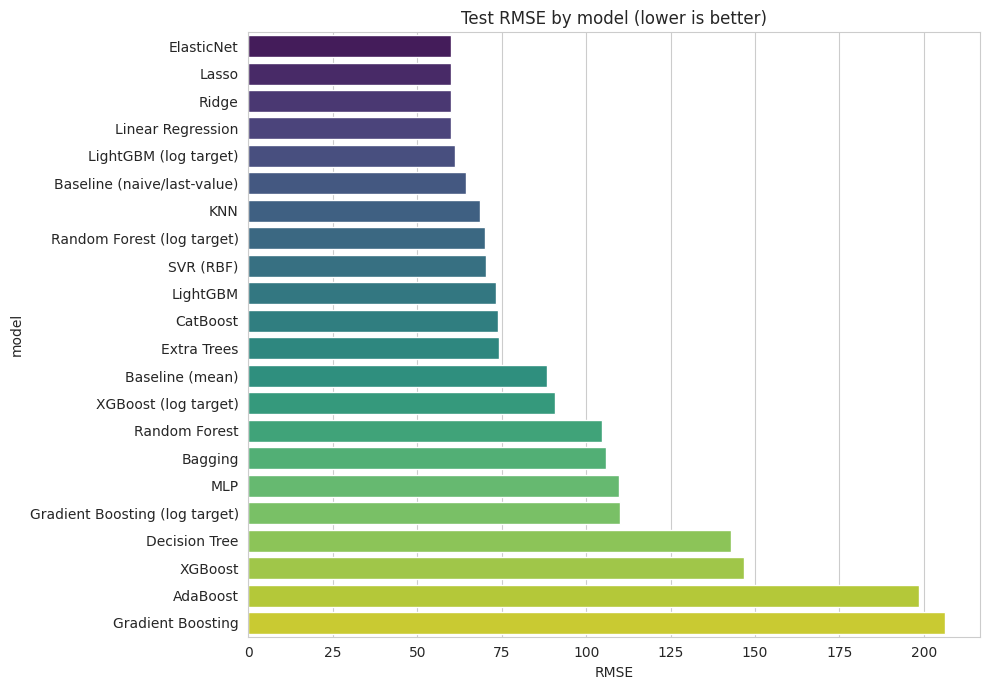


Published benchmark (Candanedo et al. 2017, Gradient Boosting): R² ≈ 0.57
Best model here: ElasticNet — R² = 0.540, RMSE = 59.9 Wh


In [20]:
plt.figure(figsize=(10, 7))
plot_df = results_df.sort_values("RMSE", ascending=True)
sns.barplot(data=plot_df, y="model", x="RMSE", palette="viridis")
plt.title("Test RMSE by model (lower is better)")
plt.tight_layout(); plt.show()

print(f"\nPublished benchmark (Candanedo et al. 2017, Gradient Boosting): R² ≈ 0.57")
best_row = results_df.iloc[0]
print(f"Best model here: {best_row['model']} — R² = {best_row['R2']:.3f}, RMSE = {best_row['RMSE']:.1f} Wh")

## 7. Hyperparameter tuning — top 2 models
Tuning uses `TimeSeriesSplit` so validation folds never look at future data relative to their training fold.

In [21]:
top2 = results_df[~results_df["model"].str.contains("Baseline")].nsmallest(2, "RMSE")["model"].tolist()
print("Tuning:", top2)

Tuning: ['ElasticNet', 'Lasso']


In [22]:
param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [8, 12, 16, None],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5, 1.0],
    },
    "Extra Trees": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [8, 12, 16, None],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "Gradient Boosting": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "n_estimators": [300, 500, 800],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        "n_estimators": [300, 500, 800],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.85, 1.0],
    },
}

def get_base_estimator(name):
    # returns (estimator_or_pipeline, param_key) matching the naming used in param_grids
    base_name = name.replace(" (log target)", "")
    if base_name == "Random Forest":
        return Pipeline([("model", RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE))]), base_name
    if base_name == "Extra Trees":
        return Pipeline([("model", ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE))]), base_name
    if base_name == "Gradient Boosting":
        return Pipeline([("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]), base_name
    if base_name == "XGBoost":
        return XGBRegressor(n_jobs=-1, random_state=RANDOM_STATE), base_name
    if base_name == "LightGBM":
        return LGBMRegressor(n_jobs=-1, random_state=RANDOM_STATE, verbose=-1), base_name
    return None, None

tuned_results = []
tuned_models = {}

for name in top2:
    base_est, key = get_base_estimator(name)
    if base_est is None or key not in param_grids:
        print(f"skip tuning for {name} (no grid defined)")
        continue

    use_log = "(log target)" in name
    y_fit = y_train_log if use_log else y_train

    search = RandomizedSearchCV(
        base_est, param_grids[key], n_iter=20, cv=tscv,
        scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1
    )
    search.fit(X_train, y_fit)

    pred = search.predict(X_test)
    if use_log:
        pred = np.expm1(pred)

    res = evaluate(f"{name} [tuned]", y_test, pred)
    tuned_results.append(res)
    tuned_models[f"{name} [tuned]"] = search.best_estimator_
    print(f"{name}: best params = {search.best_params_}")

tuned_df = pd.DataFrame(tuned_results)
tuned_df

skip tuning for ElasticNet (no grid defined)
skip tuning for Lasso (no grid defined)


""


In [23]:
final_df = pd.concat([results_df, tuned_df], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
final_df

,model,RMSE,MAE,R2,MAPE,fit_time_s
0,ElasticNet,59.908826,27.097399,0.539500,26.447603,2.178906
1,Lasso,59.919592,27.125445,0.539334,26.481537,3.397090
2,Ridge,59.921514,27.128153,0.539305,26.486314,0.052195
3,Linear Regression,59.923290,27.134431,0.539278,26.494442,0.063244
4,LightGBM (log target),61.225521,28.033478,0.519036,26.392576,1.790408
5,Baseline (naive/last-value),64.511353,25.822862,0.466026,21.865508,NaN
6,KNN,68.600278,34.793069,0.396191,35.029144,0.011878
7,Random Forest (log target),70.109617,39.179535,0.369329,39.200136,127.462345
8,SVR (RBF),70.397559,34.966138,0.364138,36.214201,15.325697
9,LightGBM,73.402840,46.953432,0.308689,55.204502,1.700714


## 8. Diagnostics for the best model

In [24]:
best_name = final_df.iloc[0]["model"]
best_model = tuned_models.get(best_name, fitted_models.get(best_name.replace(" [tuned]", "")))
use_log_best = "(log target)" in best_name

best_pred = best_model.predict(X_test)
if use_log_best:
    best_pred = np.expm1(best_pred)

print("Best model:", best_name)

Best model: ElasticNet


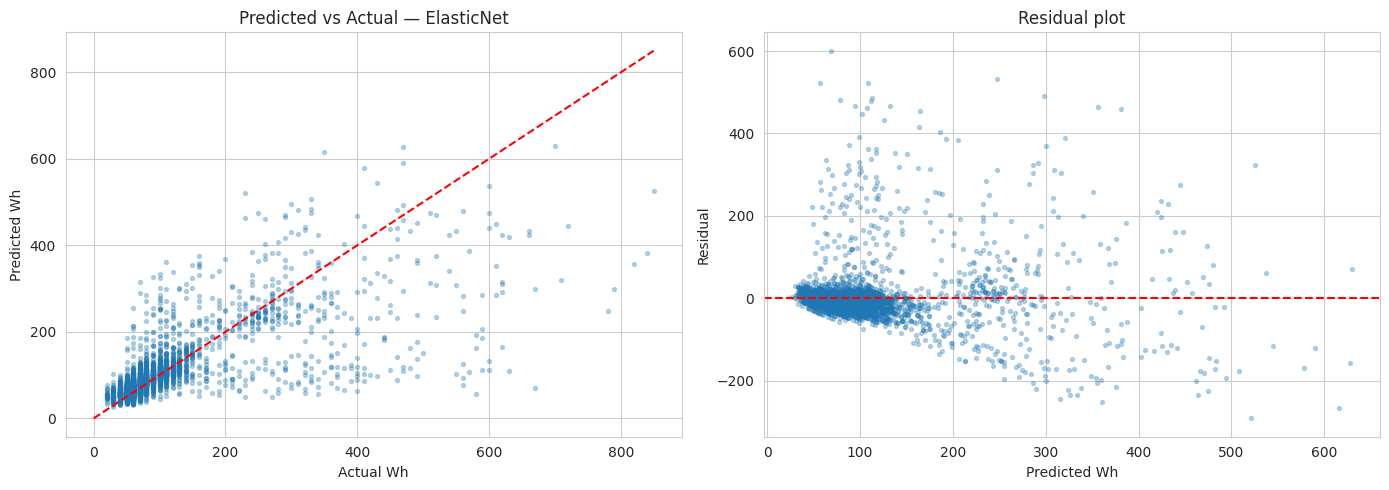

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, best_pred, alpha=0.3, s=8)
lims = [0, max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual Wh"); axes[0].set_ylabel("Predicted Wh")
axes[0].set_title(f"Predicted vs Actual — {best_name}")

residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.3, s=8)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted Wh"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual plot")
plt.tight_layout(); plt.show()

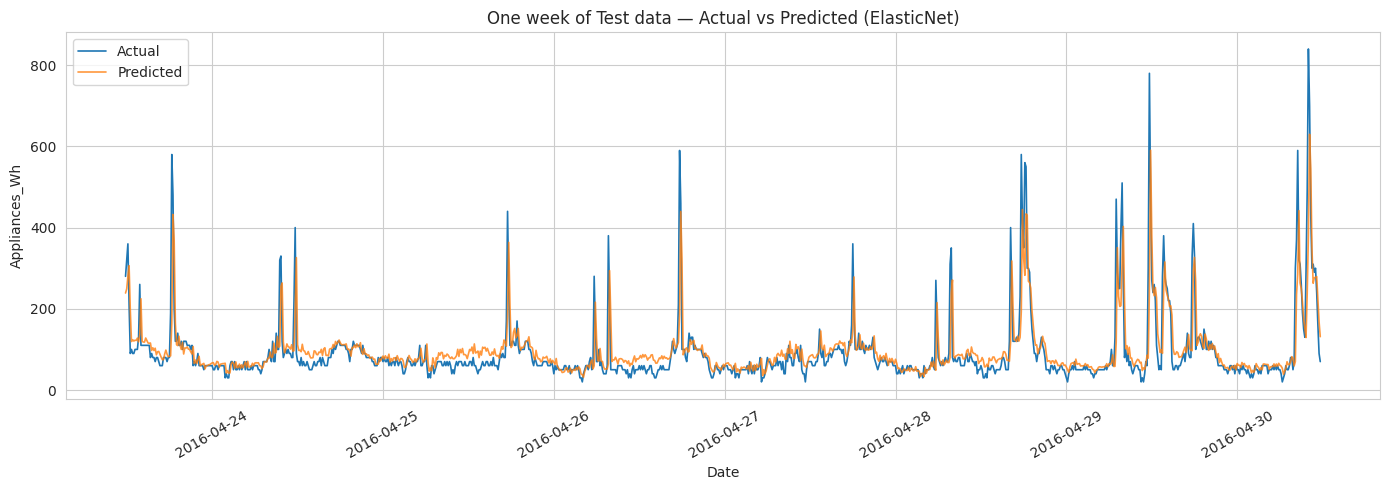

In [26]:
# One week of Test data, actual vs predicted over time
plot_dates = test_df["date"].values
week_mask = (plot_dates >= plot_dates[0]) & (plot_dates < plot_dates[0] + np.timedelta64(7, "D"))

plt.figure(figsize=(14, 5))
plt.plot(plot_dates[week_mask], y_test.values[week_mask], label="Actual", linewidth=1.2)
plt.plot(plot_dates[week_mask], best_pred[week_mask], label="Predicted", linewidth=1.2, alpha=0.8)
plt.title(f"One week of Test data — Actual vs Predicted ({best_name})")
plt.xlabel("Date"); plt.ylabel("Appliances_Wh"); plt.legend()
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 9. Interpretability — feature importance & the noise columns (`rv1`, `rv2`)

In [27]:
from sklearn.inspection import permutation_importance

# Native importance (if the model supports it)
underlying = best_model.named_steps["model"] if hasattr(best_model, "named_steps") else best_model
if hasattr(underlying, "feature_importances_"):
    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": underlying.feature_importances_
    }).sort_values("importance", ascending=False)
    plt.figure(figsize=(8, 8))
    sns.barplot(data=imp_df.head(20), y="feature", x="importance", palette="mako")
    plt.title(f"Native feature importance — {best_name}")
    plt.tight_layout(); plt.show()

    rank_rv1 = imp_df.reset_index(drop=True).index[imp_df["feature"] == "rv1"][0] + 1
    rank_rv2 = imp_df.reset_index(drop=True).index[imp_df["feature"] == "rv2"][0] + 1
    print(f"rv1 ranked #{rank_rv1} of {len(feature_cols)} features")
    print(f"rv2 ranked #{rank_rv2} of {len(feature_cols)} features")
else:
    print("Selected model has no native feature_importances_ — see permutation importance below.")

Selected model has no native feature_importances_ — see permutation importance below.


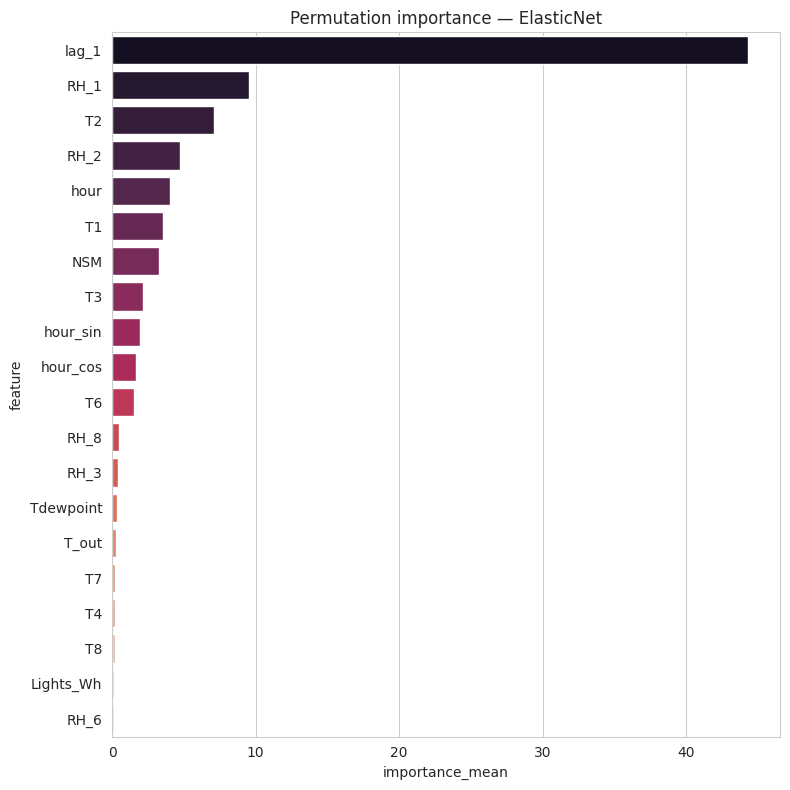

(Permutation) rv1 ranked #31 of 37 | rv2 ranked #32 of 37


In [28]:
# Permutation importance (works for any model, more reliable, but slower)
perm = permutation_importance(best_model, X_test, y_test, n_repeats=5,
                               random_state=RANDOM_STATE, n_jobs=-1, scoring="neg_root_mean_squared_error")
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=perm_df.head(20), y="feature", x="importance_mean", palette="rocket")
plt.title(f"Permutation importance — {best_name}")
plt.tight_layout(); plt.show()

rank_rv1_p = perm_df.reset_index(drop=True).index[perm_df["feature"] == "rv1"][0] + 1
rank_rv2_p = perm_df.reset_index(drop=True).index[perm_df["feature"] == "rv2"][0] + 1
print(f"(Permutation) rv1 ranked #{rank_rv1_p} of {len(feature_cols)} | rv2 ranked #{rank_rv2_p} of {len(feature_cols)}")

In [29]:
# Optional: SHAP for a deeper look (tree models only, can be slow on the full test set — sample it)
import shap
try:
    sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(underlying)
    shap_values = explainer.shap_values(sample)
    shap.summary_plot(shap_values, sample, show=True)
except Exception as e:
    print("SHAP not applicable to this model type:", e)

SHAP not applicable to this model type: Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._coordinate_descent.ElasticNet'>


## 10. Summary

- **Full leaderboard** is in `final_df` above (raw-target models, log-target variants, and tuned top-2).
- **Best model:** printed above, with its Test RMSE / MAE / R² / MAPE.
- **Benchmark comparison:** the original paper reports test R² ≈ 0.57 with Gradient Boosting — compare `final_df` against that.
- **Multicollinearity:** confirmed via VIF on `T1–T9`/`RH*`; affects linear coefficients, not tree splits.
- **Noise columns:** `rv1`/`rv2` importance ranks are printed above — a sound model/feature-selection process should push them toward the bottom.
- **Skew handling:** compare the raw-target vs log-target rows for the same algorithm in `final_df` to see which transform helped.

### Next steps for the report (max 6 pages)
1. Restate the business problem and the 5 EDA insights.
2. Show the leaderboard table + RMSE bar chart.
3. Discuss multicollinearity (VIF) and how it shows up in Ridge/Lasso vs Random Forest/XGBoost coefficients/importances.
4. Discuss the rv1/rv2 result as evidence your feature-selection process works.
5. Show predicted-vs-actual, residuals, and the one-week time plot for the best model.
6. Compare your best R² to the paper's ≈0.57 and explain why (extra lag/rolling features usually beat the original paper, which didn't use them).

In [30]:
# Save results and requirements for the deliverables
final_df.to_csv("model_comparison_results.csv", index=False)

requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
statsmodels
xgboost
lightgbm
catboost
shap
"""
with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Saved model_comparison_results.csv and requirements.txt")

Saved model_comparison_results.csv and requirements.txt
